In [18]:
# Bloco A1 — CONSOLIDADO (OSMI 2018)
# - Lê o CSV
# - Detecta automaticamente a coluna-alvo (qualquer coluna contendo "treat")
# - Normaliza o alvo para binário (0/1) e filtra linhas inválidas
# - Remove colunas 100% nulas e de baixíssima variância (0 ou 1 valor distinto)
# - Remove identificadores/texto livre comuns
# - Separa numéricas/categóricas e remove categóricas de altíssima cardinalidade
# - Exporta: df, X_raw, X, y, num_cols, cat_cols

import os
import numpy as np
import pandas as pd

# >>> Ajuste o caminho conforme sua máquina:
PATH = r"C:\Users\pedro\Downloads\IA-CP2\osmi.csv"
if not os.path.exists(PATH):
    PATH = "osmi.csv"

df = pd.read_csv(PATH)

# 1) Detecta a coluna do alvo (qualquer nome contendo 'treat')
cand_alvos = [c for c in df.columns if "treat" in c.lower()]
if not cand_alvos:
    raise ValueError(
        "Não encontrei nenhuma coluna com 'treat' no nome (ex.: 'treatment', 'seek_treatment'). "
        f"Algumas colunas disponíveis: {list(df.columns)[:12]} ..."
    )
alvo_col = "treatment" if "treatment" in df.columns else cand_alvos[0]
print(f"[A1] Usando coluna-alvo: {alvo_col!r}")

# 2) Normaliza o alvo para 0/1
map_bin = {"yes":1, "no":0, "true":1, "false":0, "1":1, "0":0, "y":1, "n":0}
y_raw = df[alvo_col].astype(str).str.strip().str.lower()
y = y_raw.map(map_bin)
mask_valid = y.isin([0, 1])

if not mask_valid.all():
    drop_count = int((~mask_valid).sum())
    print(f"[A1] Removendo {drop_count} linha(s) com alvo inválido (valores não mapeáveis).")

df = df.loc[mask_valid].reset_index(drop=True)
y  = y.loc[mask_valid].reset_index(drop=True)

# 3) Prepara X bruto removendo alvo e alguns campos comumente inúteis para predição
drop_candidates = [alvo_col, "comments", "Timestamp", "timestamp", "ID", "id"]
drop_cols_present = [c for c in drop_candidates if c in df.columns]
X_raw = df.drop(columns=drop_cols_present)

# 4) Remove colunas 100% nulas e colunas de baixíssima variância (0 ou 1 valor distinto)
all_null = [c for c in X_raw.columns if X_raw[c].isna().all()]
if all_null:
    print(f"[A1] Removendo colunas 100% nulas: {all_null[:8]}{' ...' if len(all_null) > 8 else ''}")
    X_raw = X_raw.drop(columns=all_null)

low_var = [c for c in X_raw.columns if X_raw[c].nunique(dropna=True) <= 1]
if low_var:
    print(f"[A1] Removendo colunas de baixíssima variância: {low_var[:8]}{' ...' if len(low_var) > 8 else ''}")
    X_raw = X_raw.drop(columns=low_var)

# 5) Tipos: separa numéricas e categóricas
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

# 6) Remove categóricas de altíssima cardinalidade (texto livre, etc.)
HIGH_CARD_THRESH = 60
high_card = [c for c in cat_cols if X_raw[c].nunique(dropna=True) > HIGH_CARD_THRESH]
if high_card:
    print(f"[A1] Removendo categóricas de alta cardinalidade (> {HIGH_CARD_THRESH}): {high_card[:8]}{' ...' if len(high_card) > 8 else ''}")
cat_cols = [c for c in cat_cols if c not in high_card]

# 7) Monta X final
X = X_raw[num_cols + cat_cols].copy()

# 8) Resumo
print(f"[A1] Linhas após filtro: {df.shape[0]}")
print(f"[A1] Features originais (após drops básicos): {X_raw.shape[1]}")
print(f"[A1] Usadas no modelo: {X.shape[1]}  |  Numéricas: {len(num_cols)}  |  Categóricas: {len(cat_cols)}")
if drop_cols_present:
    print(f"[A1] Removidas por serem alvo/ID/texto livre: {drop_cols_present}")
print("\n[A1] Balanceamento do alvo (0=No, 1=Yes):")
print(y.value_counts())
print((y.value_counts(normalize=True)*100).round(2).astype(str) + " %")

# Mantém df, X_raw, X, y, num_cols, cat_cols para os próximos blocos (A2, A3, A4, A5)


[A1] Usando coluna-alvo: 'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'
[A1] Removendo 277 linha(s) com alvo inválido (valores não mapeáveis).
[A1] Removendo colunas 100% nulas: ['Do you have medical coverage (private insurance or state-provided) that includes treatment of mental health disorders?', 'Do you know local or online resources to seek help for a mental health issue?', '<strong>If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?</strong>', 'If you have revealed a mental health disorder to a client or business contact, how has this affected you or the relationship?', '<strong>If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?</strong>', 'If you have revealed a mental health disorder to a coworker or employee, how has this impacted you or the 

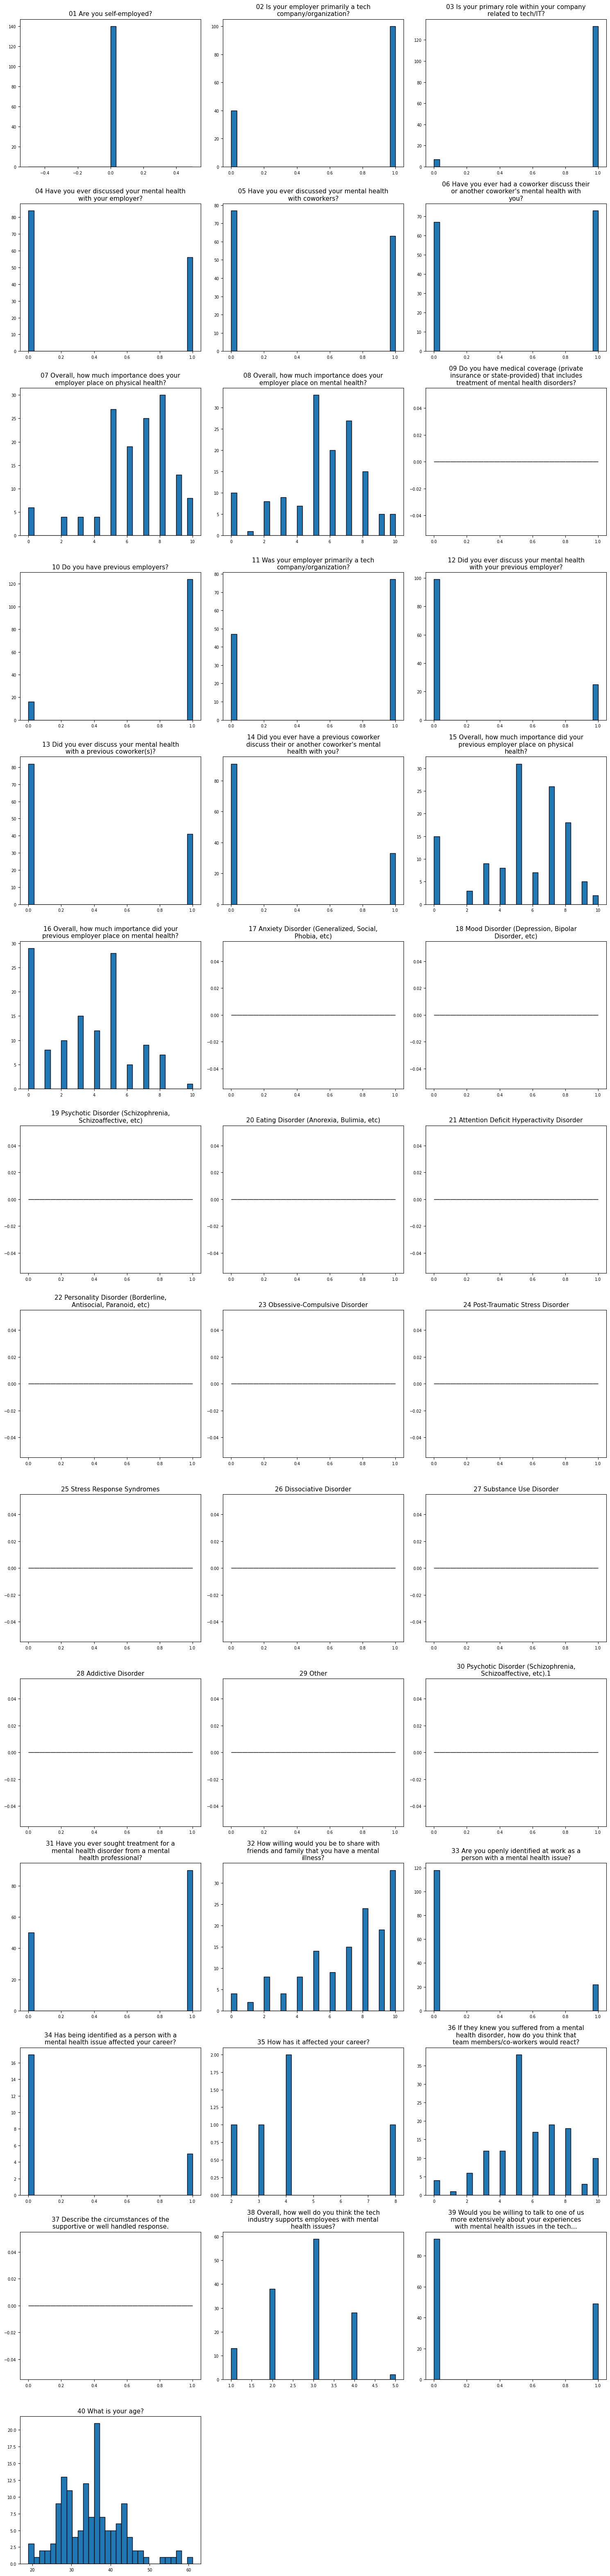

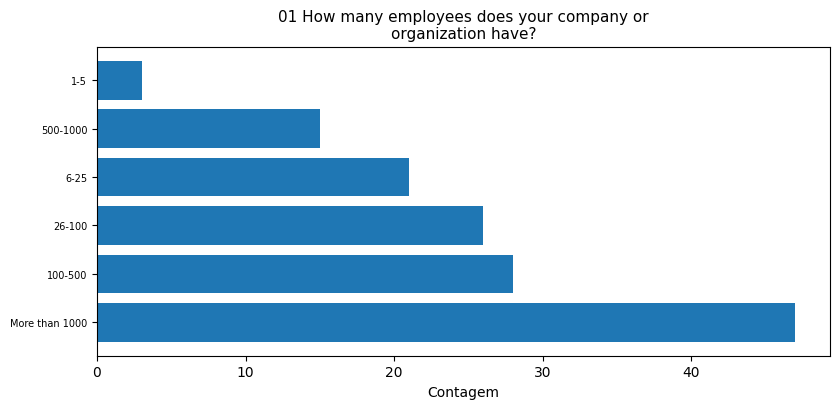

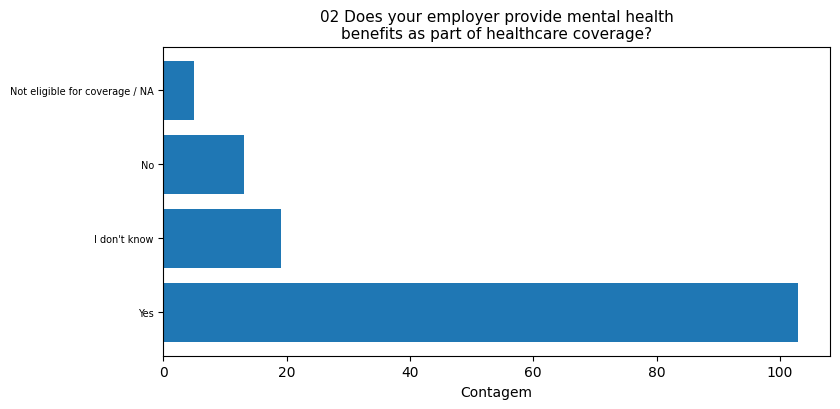

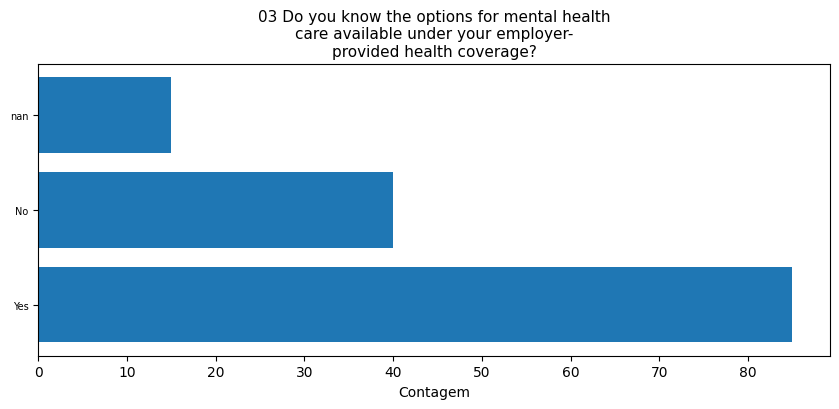

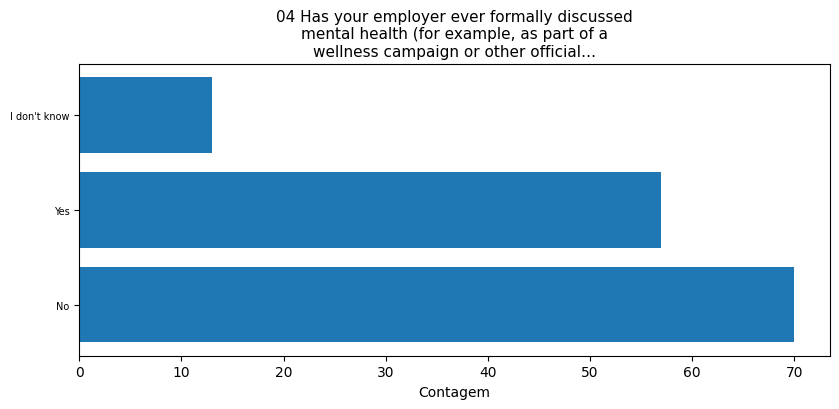

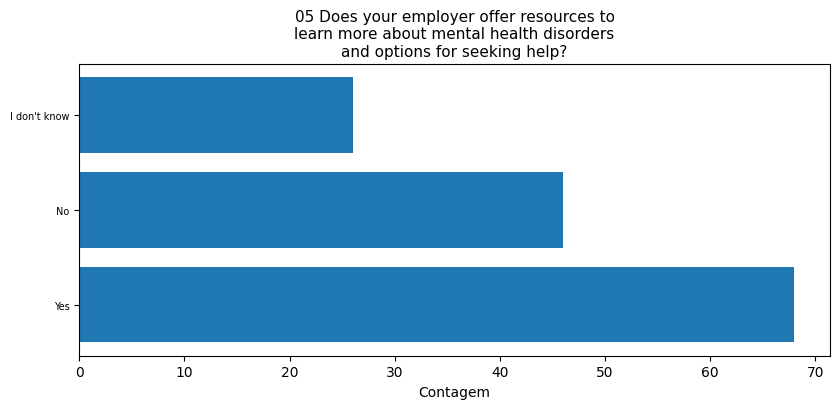

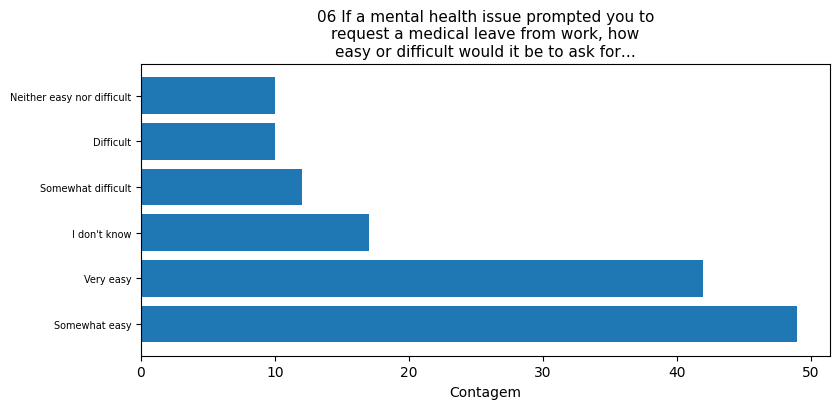

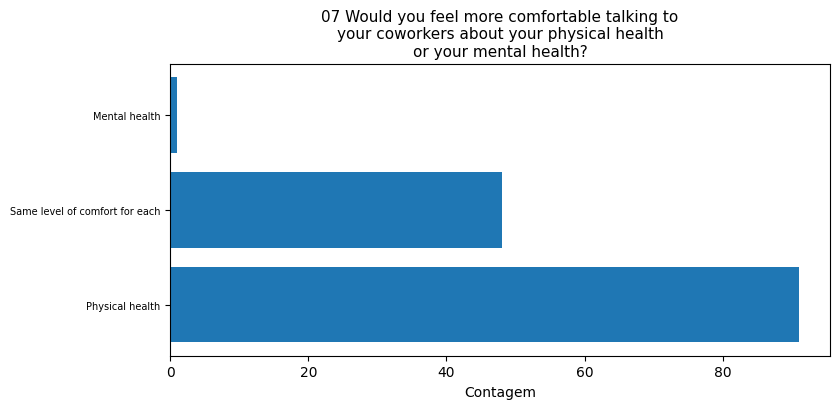

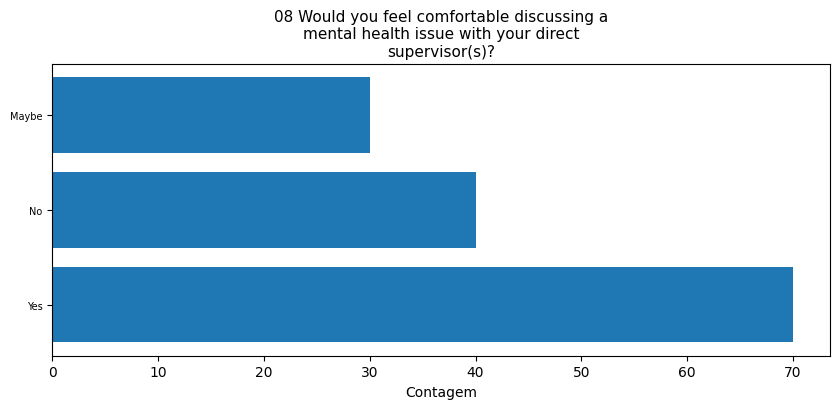

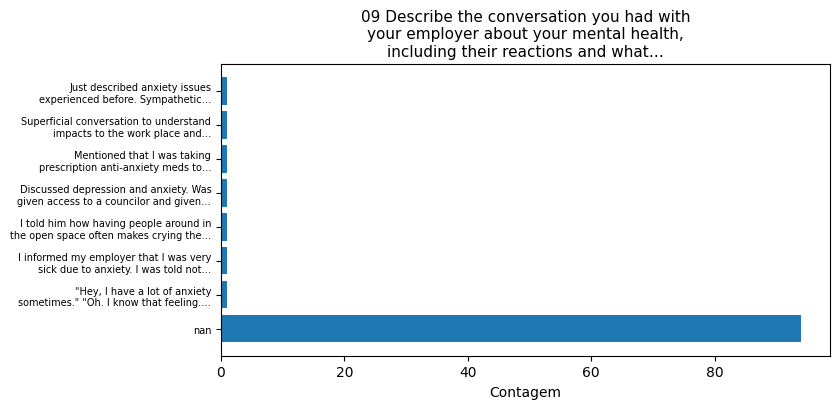

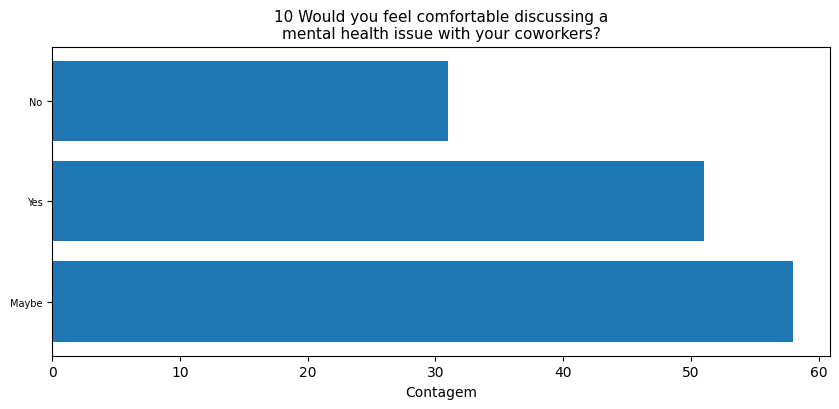

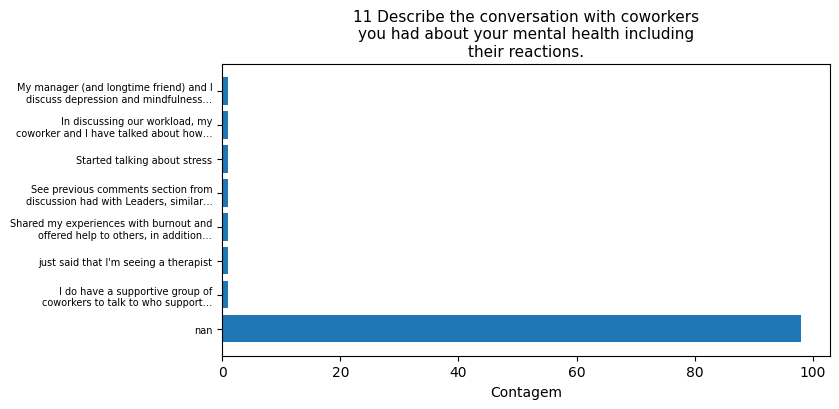

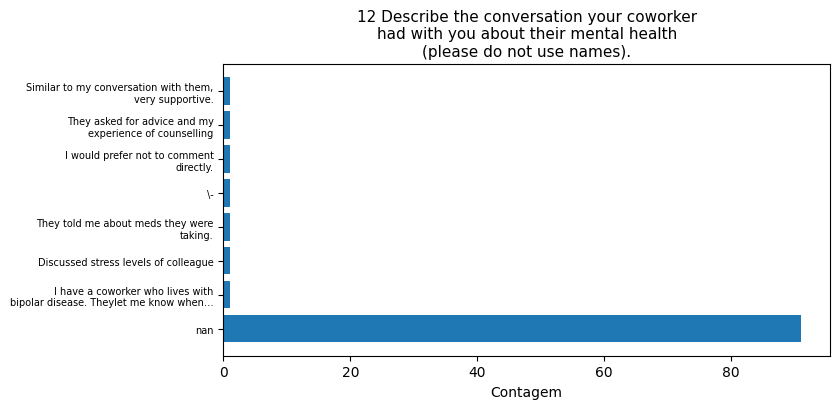

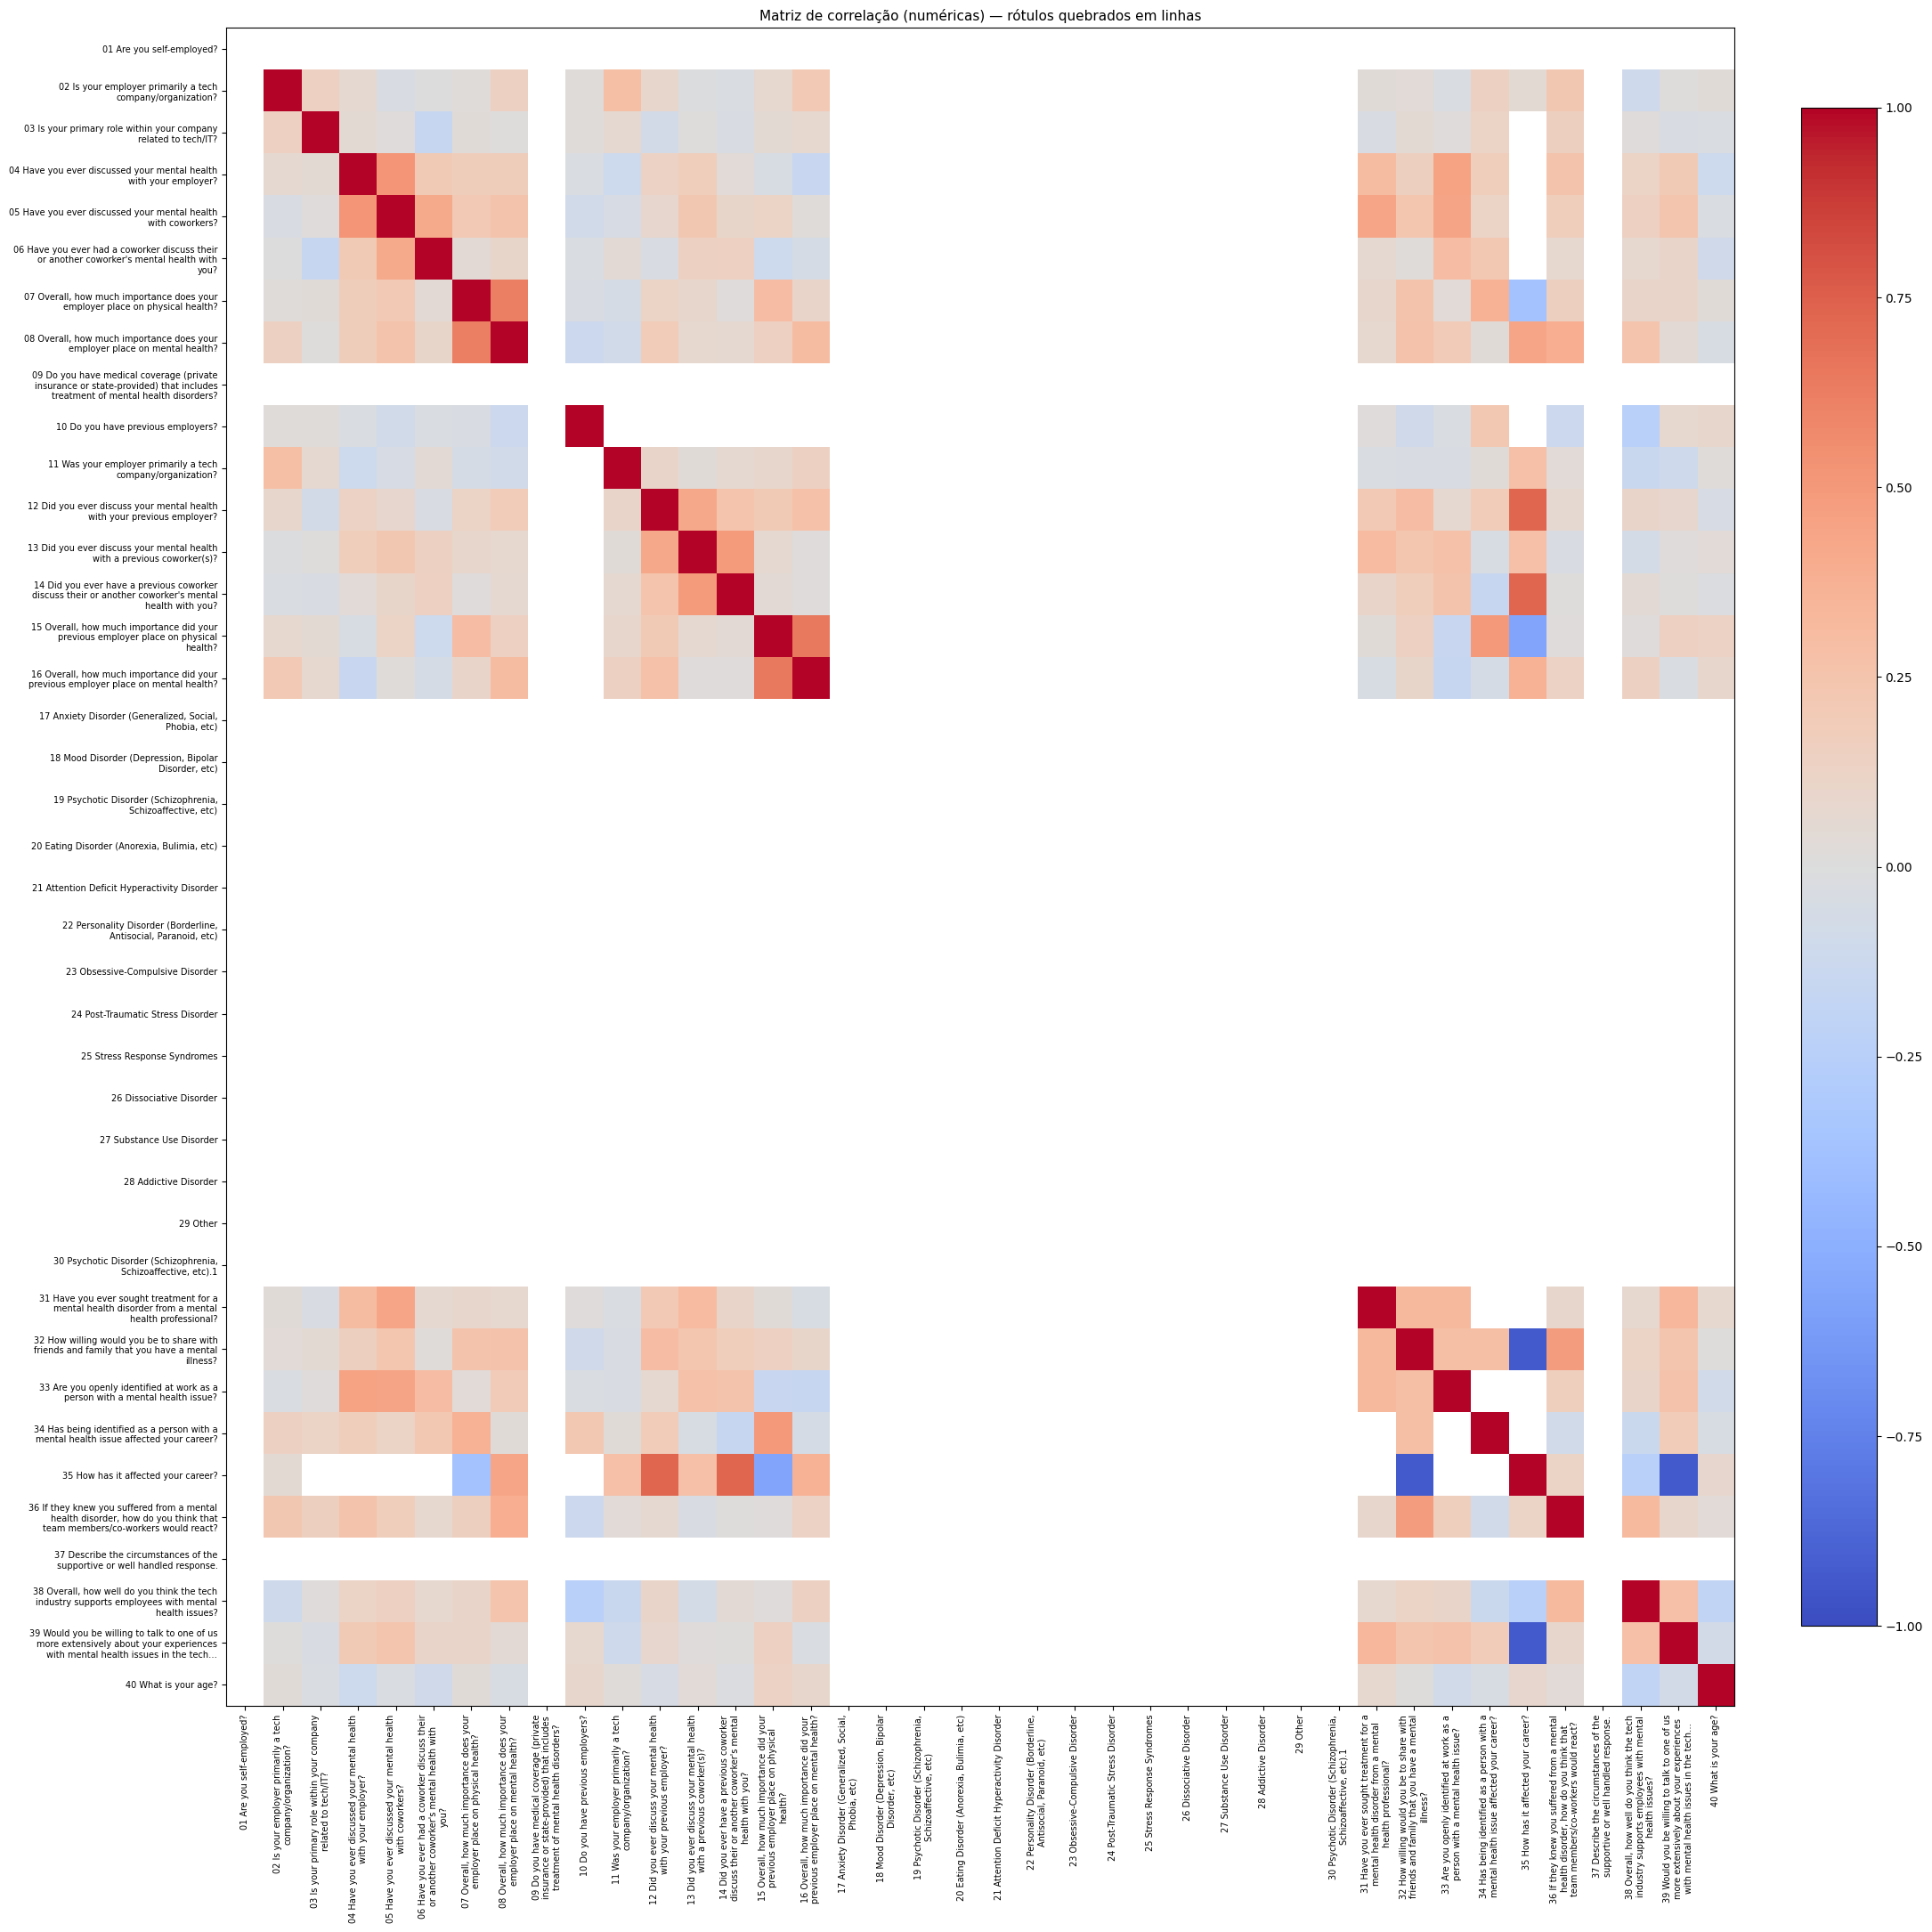


Mapeamento — NUMÉRICAS (primeiras 25):


,original,rotulo_usado
0,<strong>Are you self-employed?</strong>,01 Are you self-employed?
1,Is your employer primarily a tech company/orga...,02 Is your employer primarily a tech\ncompany/...
2,Is your primary role within your company relat...,03 Is your primary role within your company\nr...
3,Have you ever discussed your mental health wit...,04 Have you ever discussed your mental health\...
4,Have you ever discussed your mental health wit...,05 Have you ever discussed your mental health\...
5,Have you ever had a coworker discuss their or ...,06 Have you ever had a coworker discuss their\...
6,"Overall, how much importance does your employe...","07 Overall, how much importance does your\nemp..."
7,"Overall, how much importance does your employe...","08 Overall, how much importance does your\nemp..."
8,Do you have medical coverage (private insuranc...,09 Do you have medical coverage (private\ninsu...
9,<strong>Do you have previous employers?</strong>,10 Do you have previous employers?



Mapeamento — CATEGÓRICAS (primeiras 25):


,original,rotulo_usado
0,How many employees does your company or organi...,01 How many employees does your company or\nor...
1,Does your employer provide mental health benef...,02 Does your employer provide mental health\nb...
2,Do you know the options for mental health care...,03 Do you know the options for mental health\n...
3,Has your employer ever formally discussed ment...,04 Has your employer ever formally discussed\n...
4,Does your employer offer resources to learn mo...,05 Does your employer offer resources to\nlear...
5,If a mental health issue prompted you to reque...,06 If a mental health issue prompted you to\nr...
6,Would you feel more comfortable talking to you...,07 Would you feel more comfortable talking to\...
7,Would you feel comfortable discussing a mental...,08 Would you feel comfortable discussing a\nme...
8,Describe the conversation you had with your em...,09 Describe the conversation you had with\nyou...
9,Would you feel comfortable discussing a mental...,10 Would you feel comfortable discussing a\nme...


In [12]:
# Bloco A2 — EDA legível (menos abreviação: quebra em múltiplas linhas)

import re, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---------- Parâmetros (ajuste conforme sua tela/print) ----------
WRAP_WIDTH_COL   = 42   # ~caracteres por linha para NOME DE COLUNA (eixo dos gráficos)
WRAP_WIDTH_CAT   = 38   # ~caracteres por linha para VALORES CATEGÓRICOS
MAX_LINES_COL    = 3    # máx. de linhas para nome de coluna (até ~ 3*42 ≈ 126 chars)
MAX_LINES_CAT    = 2    # máx. de linhas para cada valor categórico
MAX_CATS_SHOWN   = 8    # top N categorias por coluna categórica
FS_TICKS         = 7    # fontsize dos ticks
FS_TITLE         = 11   # fontsize do título
# ---------------------------------------------------------------

def clean_text(s: str) -> str:
    """Remove HTML e espaços excessivos."""
    s = re.sub(r"<.*?>", "", str(s))
    s = re.sub(r"\s+", " ", s).strip()
    return s

def wrap_text(s: str, width: int, max_lines: int) -> str:
    """Quebra em múltiplas linhas sem cortar agressivamente.
       Se ultrapassar max_lines, mantém as primeiras linhas e sinaliza com '…' no fim."""
    s = clean_text(s)
    lines = textwrap.wrap(s, width=width, break_long_words=False)
    if len(lines) <= max_lines:
        return "\n".join(lines)
    # mantém (max_lines-1) + última parte condensada
    kept = lines[:max_lines]
    kept[-1] = textwrap.shorten(kept[-1] + " " + " ".join(lines[max_lines:]),
                                width=width, placeholder="…")
    return "\n".join(kept)

# Rótulos "longos porém legíveis" (com prefixo numérico para referência)
num_label = {c: f"{i:02d} {wrap_text(c, WRAP_WIDTH_COL, MAX_LINES_COL)}"
             for i, c in enumerate(num_cols, 1)}
cat_label = {c: f"{i:02d} {wrap_text(c, WRAP_WIDTH_COL, MAX_LINES_COL)}"
             for i, c in enumerate(cat_cols, 1)}

# ---------------- Histogramas das numéricas -----------------
if len(num_cols) > 0:
    n = len(num_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, num_cols):
        ax.hist(X[col].dropna(), bins=30, edgecolor="black")
        ax.set_title(num_label[col], fontsize=FS_TITLE)
        ax.tick_params(axis="both", labelsize=FS_TICKS)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# ------------- Barras HORIZONTAIS para categóricas ----------
for c in cat_cols[:12]:  # limite pra não poluir a saída
    vc = X[c].value_counts(dropna=False).head(MAX_CATS_SHOWN)
    labels = [wrap_text(str(k), WRAP_WIDTH_CAT, MAX_LINES_CAT) for k in vc.index]

    plt.figure(figsize=(8.5, 4.2))
    y_pos = np.arange(len(vc))
    plt.barh(y_pos, vc.values)
    plt.yticks(y_pos, labels, fontsize=FS_TICKS)
    plt.xlabel("Contagem")
    plt.title(cat_label[c], fontsize=FS_TITLE)
    plt.tight_layout()
    plt.show()

# ---------------- Heatmap de correlação (numéricas) ----------
if len(num_cols) > 1:
    corr = X[num_cols].corr(numeric_only=True)
    # aplica rótulos quebrados
    corr.index = [num_label[c] for c in corr.index]
    corr.columns = [num_label[c] for c in corr.columns]

    side = min(0.42 * len(corr.columns) + 5, 22)  # escala dinâmica com teto
    plt.figure(figsize=(side, side))
    im = plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=FS_TICKS)
    plt.yticks(range(len(corr.index)), corr.index, fontsize=FS_TICKS)
    plt.title("Matriz de correlação (numéricas) — rótulos quebrados em linhas", fontsize=FS_TITLE)
    plt.tight_layout()
    plt.show()

# --------- Mapeamento de referência (original -> rótulo usado) ---------
map_num = pd.DataFrame({"original": num_cols, "rotulo_usado": [num_label[c] for c in num_cols]})
map_cat = pd.DataFrame({"original": cat_cols, "rotulo_usado": [cat_label[c] for c in cat_cols]})
print("\nMapeamento — NUMÉRICAS (primeiras 25):")
display(map_num.head(25))
print("\nMapeamento — CATEGÓRICAS (primeiras 25):")
display(map_cat.head(25))

# Dicas:
# • Quer ainda menos abreviação? Aumente WRAP_WIDTH_COL/WRAP_WIDTH_CAT ou MAX_LINES_COL/MAX_LINES_CAT.
# • Para prints em PDF, antes de plt.show(), você pode usar:
#     plt.savefig("fig_nome.png", dpi=300, bbox_inches="tight")


In [14]:
# Bloco A3 — GridSearchCV (OneHot + Scale + LogisticRegression L1/L2) — versão compatível
# Corrige o erro do OneHotEncoder (usa 'sparse_output' em versões novas e 'sparse' nas antigas).
# Também lida com o caso de não haver colunas numéricas ou categóricas.

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Pré-processamento (numérico)
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pré-processamento (categórico) — cria OneHotEncoder compatível com várias versões do sklearn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)         # sklearn < 1.2

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

# Monta o ColumnTransformer apenas com o que existir
transformers = []
if len(num_cols) > 0:
    transformers.append(("num", num_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(("cat", cat_pipe, cat_cols))

pre = ColumnTransformer(transformers, remainder="drop")

# Pipeline final
pipe = Pipeline([
    ("pre", pre),
    ("logreg", LogisticRegression(solver="liblinear", max_iter=2000))
])

# Grade de hiperparâmetros
param_grid = {
    "logreg__penalty": ["l1", "l2"],
    "logreg__C": [0.01, 0.1, 1, 10, 100]
}

# Validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print(f"Melhor acurácia média (validação 5-fold): {grid.best_score_:.4f}")

# Resumo da busca
res = pd.DataFrame(grid.cv_results_)
cols = ["param_logreg__penalty", "param_logreg__C", "mean_test_score", "std_test_score", "rank_test_score"]
display(res[cols].sort_values("rank_test_score").reset_index(drop=True).round(4))


Melhores parâmetros: {'logreg__C': 0.1, 'logreg__penalty': 'l2'}
Melhor acurácia média (validação 5-fold): 0.8929


C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Do you have medical coverage (private insurance or state-provided) that includes treatment of mental health disorders?'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)'
 'Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Psychotic Disorder (Schizophrenia, Schizoaffective, etc)'
 'Eating Disorder (Anorexia, Bulimia, etc)'
 'Attention Deficit Hyperactivity Disorder'
 'Personality Disorder (Borderline, Antisocial, Paranoid, etc)'
 'Obsessive-Compulsive Disorder' 'Post-Traumatic Stress Disorder'
 'Stress Response Syndromes' 'Dissociative Disorder'
 'Substance Use Disorder' 'Addictive Disorder' 'Other'
 'Psychotic Disorder (Schizophrenia, Schizoaffective, etc).1'
 'Describe the circumstances of the supportive or well handled response.']. At least one non-m

,param_logreg__penalty,param_logreg__C,mean_test_score,std_test_score,rank_test_score
0,l2,0.10,0.8929,0.0360,1
1,l2,10.00,0.8921,0.0472,2
2,l2,0.01,0.8842,0.0204,3
3,l1,1.00,0.8834,0.0466,4
4,l2,1.00,0.8834,0.0376,4
5,l2,100.00,0.8830,0.0475,6
6,l1,100.00,0.8826,0.0742,7
7,l1,0.10,0.8751,0.0172,8
8,l1,10.00,0.8648,0.0654,9
9,l1,0.01,0.1158,0.0204,10


=== Métricas no TESTE ===
Acurácia : 0.9643
Precisão : 0.9615
Recall   : 1.0000
F1-score : 0.9804

Relatório por classe:
              precision    recall  f1-score   support

       No(0)       1.00      0.67      0.80         3
      Yes(1)       0.96      1.00      0.98        25

    accuracy                           0.96        28
   macro avg       0.98      0.83      0.89        28
weighted avg       0.97      0.96      0.96        28



C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Do you have medical coverage (private insurance or state-provided) that includes treatment of mental health disorders?'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)'
 'Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Psychotic Disorder (Schizophrenia, Schizoaffective, etc)'
 'Eating Disorder (Anorexia, Bulimia, etc)'
 'Attention Deficit Hyperactivity Disorder'
 'Personality Disorder (Borderline, Antisocial, Paranoid, etc)'
 'Obsessive-Compulsive Disorder' 'Post-Traumatic Stress Disorder'
 'Stress Response Syndromes' 'Dissociative Disorder'
 'Substance Use Disorder' 'Addictive Disorder' 'Other'
 'Psychotic Disorder (Schizophrenia, Schizoaffective, etc).1'
 'Describe the circumstances of the supportive or well handled response.']. At least one non-m

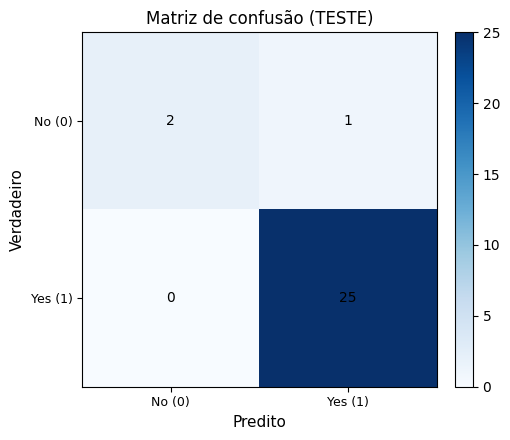

C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Do you have medical coverage (private insurance or state-provided) that includes treatment of mental health disorders?'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)'
 'Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Psychotic Disorder (Schizophrenia, Schizoaffective, etc)'
 'Eating Disorder (Anorexia, Bulimia, etc)'
 'Attention Deficit Hyperactivity Disorder'
 'Personality Disorder (Borderline, Antisocial, Paranoid, etc)'
 'Obsessive-Compulsive Disorder' 'Post-Traumatic Stress Disorder'
 'Stress Response Syndromes' 'Dissociative Disorder'
 'Substance Use Disorder' 'Addictive Disorder' 'Other'
 'Psychotic Disorder (Schizophrenia, Schizoaffective, etc).1'
 'Describe the circumstances of the supportive or well handled response.']. At least one non-m

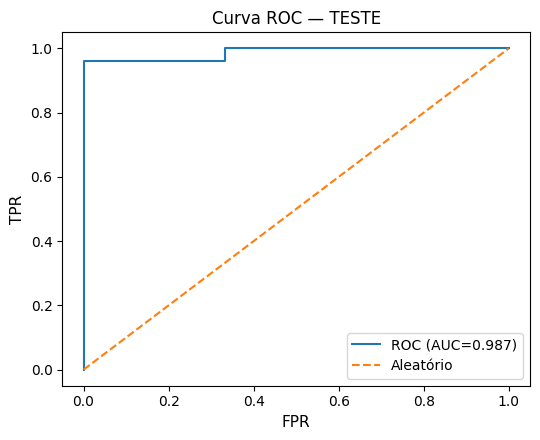

In [15]:
# Bloco A4 — Avaliação no TESTE (com gráficos legíveis)
# - Métricas: Accuracy, Precision, Recall, F1
# - Matriz de confusão com anotações e rótulos legíveis
# - Curva ROC + AUC (opcional)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc)

# Parâmetros visuais (mesmo espírito do A2; ajuste se quiser)
FS_TICKS   = 9
FS_TITLE   = 12
FS_LABEL   = 11

best = grid.best_estimator_
y_pred = best.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print("=== Métricas no TESTE ===")
print(f"Acurácia : {acc:.4f}")
print(f"Precisão : {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Relatório por classe:")
print(classification_report(y_test, y_pred, target_names=["No(0)", "Yes(1)"], zero_division=0))

# Matriz de Confusão (com anotações)
cm = confusion_matrix(y_test, y_pred)
classes = ["No (0)", "Yes (1)"]

plt.figure(figsize=(5.5, 4.5))
im = plt.imshow(cm, cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(2), classes, fontsize=FS_TICKS)
plt.yticks(range(2), classes, fontsize=FS_TICKS)
plt.xlabel("Predito", fontsize=FS_LABEL)
plt.ylabel("Verdadeiro", fontsize=FS_LABEL)
plt.title("Matriz de confusão (TESTE)", fontsize=FS_TITLE)

# anotações nos quadrantes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=FS_TICKS+1)

plt.tight_layout()
plt.show()

# Curva ROC (opcional, mas útil)
if hasattr(best, "predict_proba"):
    y_proba = best.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = auc(fpr, tpr)

    plt.figure(figsize=(5.5, 4.5))
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc_val:.3f})")
    plt.plot([0,1], [0,1], "--", label="Aleatório")
    plt.xlabel("FPR", fontsize=FS_LABEL)
    plt.ylabel("TPR", fontsize=FS_LABEL)
    plt.title("Curva ROC — TESTE", fontsize=FS_TITLE)
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Do you have medical coverage (private insurance or state-provided) that includes treatment of mental health disorders?'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)'
 'Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Psychotic Disorder (Schizophrenia, Schizoaffective, etc)'
 'Eating Disorder (Anorexia, Bulimia, etc)'
 'Attention Deficit Hyperactivity Disorder'
 'Personality Disorder (Borderline, Antisocial, Paranoid, etc)'
 'Obsessive-Compulsive Disorder' 'Post-Traumatic Stress Disorder'
 'Stress Response Syndromes' 'Dissociative Disorder'
 'Substance Use Disorder' 'Addictive Disorder' 'Other'
 'Psychotic Disorder (Schizophrenia, Schizoaffective, etc).1'
 'Describe the circumstances of the supportive or well handled response.']. At least one non-m

Total de features zeradas pelo L1: 429
Algumas zeradas: ['num__<strong>Are you self-employed?</strong>', 'num__Is your employer primarily a tech company/organization?', 'num__Is your primary role within your company related to tech/IT?', 'num__Have you ever discussed your mental health with your employer?', 'num__Have you ever discussed your mental health with coworkers?', 'num__<strong>Do you have previous employers?</strong>', 'num__Was your employer primarily a tech company/organization?', 'num__Did you ever discuss your mental health with your previous employer?', 'num__Overall, how much importance did your previous employer place on mental health?', 'num__Have you ever sought treatment for a mental health disorder from a mental health professional?', 'num__Are you openly identified at work as a person with a mental health issue?', 'num__Would you be willing to talk to one of us more extensively about your experiences with mental health issues in the tech industry? (Note that all i

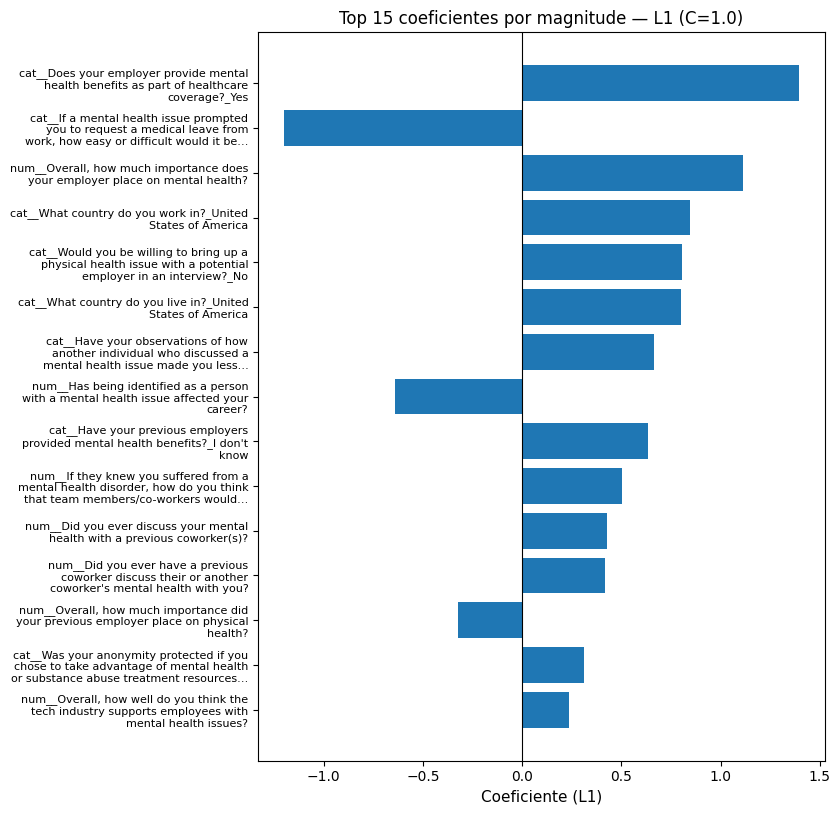

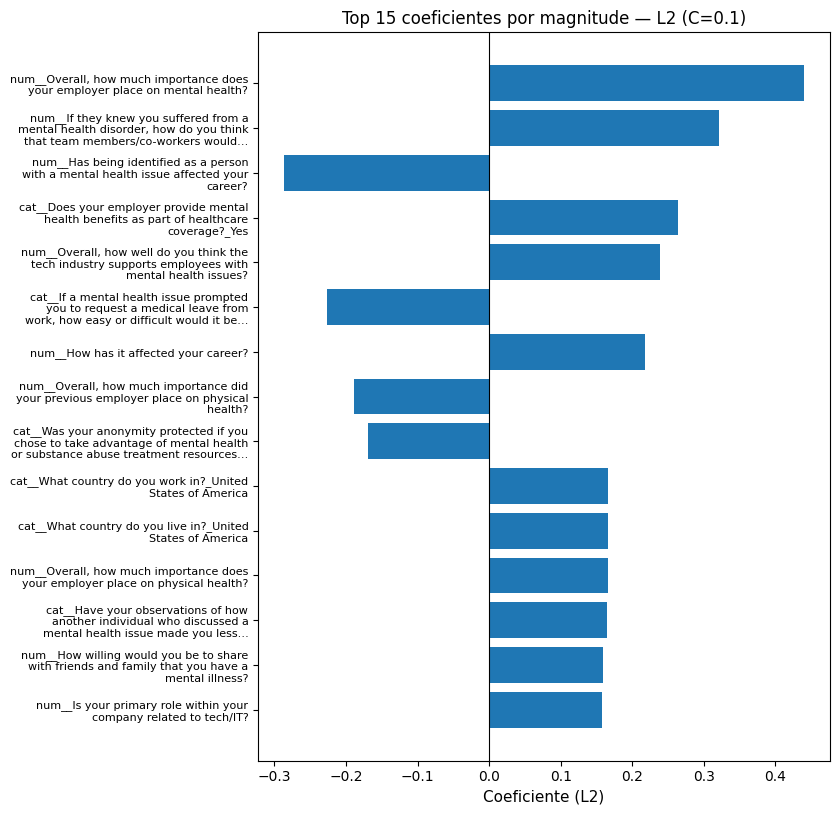


Comparação (primeiras 20 linhas):


,feature,label,coef_L1,coef_L2
33,cat__Does your employer provide mental health ...,cat__Does your employer provide mental\nhealth...,1.396198,0.264553
42,cat__If a mental health issue prompted you to ...,cat__If a mental health issue prompted\nyou to...,-1.200697,-0.226755
7,"num__Overall, how much importance does your em...","num__Overall, how much importance does\nyour e...",1.112470,0.440023
427,cat__What country do you <strong>work</strong>...,cat__What country do you work in?_United\nStat...,0.845778,0.166254
288,cat__Would you be willing to bring up a physic...,cat__Would you be willing to bring up a\nphysi...,0.804244,0.145992
380,cat__What country do you <strong>live</strong>...,cat__What country do you live in?_United\nStat...,0.802578,0.166254
285,cat__Have your observations of how another ind...,cat__Have your observations of how\nanother in...,0.664949,0.165232
18,num__Has being identified as a person with a m...,num__Has being identified as a person\nwith a ...,-0.638753,-0.286397
165,cat__<strong>Have your previous employers prov...,cat__Have your previous employers\nprovided me...,0.632548,0.127961
20,num__If they knew you suffered from a mental h...,num__If they knew you suffered from a\nmental ...,0.502028,0.321232


In [16]:
# Bloco A5 — L1 vs L2: coeficientes, features zeradas e gráficos legíveis
# - Ajusta dois pipelines (L1 e L2) com o melhor C de cada penalidade
# - Lista coeficientes e mostra top por magnitude
# - Plota barh com rótulos quebrados em linhas (legíveis)
# - Reporta features zeradas pelo L1 (seleção)

import re, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Helpers para rótulos longos (mesma ideia do A2)
WRAP_WIDTH_COL = 40
MAX_LINES_COL  = 3
FS_TICKS       = 8
FS_TITLE       = 12
FS_LABEL       = 11
TOP_N          = 15  # quantos coeficientes mostrar por gráfico

def clean_text(s: str) -> str:
    s = re.sub(r"<.*?>", "", str(s))
    s = re.sub(r"\s+", " ", s).strip()
    return s

def wrap_text(s: str, width: int, max_lines: int) -> str:
    s = clean_text(s)
    lines = textwrap.wrap(s, width=width, break_long_words=False)
    if len(lines) <= max_lines: return "\n".join(lines)
    kept = lines[:max_lines]
    kept[-1] = textwrap.shorten(kept[-1] + " " + " ".join(lines[max_lines:]),
                                width=width, placeholder="…")
    return "\n".join(kept)

# Melhor C por penalidade a partir do grid
cvres = pd.DataFrame(grid.cv_results_)
best_C = {}
for pen in ["l1", "l2"]:
    sub = cvres[cvres["param_logreg__penalty"] == pen][["param_logreg__C", "mean_test_score"]]
    best_C[pen] = float(sub.sort_values("mean_test_score", ascending=False).iloc[0]["param_logreg__C"]) if len(sub) else 1.0

def fit_with(penalty, Cval):
    pipe_p = Pipeline([
        ("pre", pre),
        ("logreg", LogisticRegression(solver="liblinear", penalty=penalty, C=Cval, max_iter=2000))
    ])
    return pipe_p.fit(X_train, y_train)

m_l1 = fit_with("l1", best_C["l1"])
m_l2 = fit_with("l2", best_C["l2"])

# Nomes de features após o pré-processamento
feat_names = m_l1.named_steps["pre"].get_feature_names_out()
feat_labels = [wrap_text(f, WRAP_WIDTH_COL, MAX_LINES_COL) for f in feat_names]

coef_l1 = m_l1.named_steps["logreg"].coef_.ravel()
coef_l2 = m_l2.named_steps["logreg"].coef_.ravel()

comp = pd.DataFrame({
    "feature": feat_names,
    "label":   feat_labels,
    "coef_L1": coef_l1,
    "coef_L2": coef_l2,
    "abs_L1":  np.abs(coef_l1),
    "abs_L2":  np.abs(coef_l2)
})

# Features zeradas no L1 (seleção)
zeradas = comp[np.isclose(comp["coef_L1"], 0.0, atol=1e-12)]["feature"].tolist()
print(f"Total de features zeradas pelo L1: {len(zeradas)}")
print("Algumas zeradas:", zeradas[:20])

# Top por magnitude (L1)
top_l1 = comp.sort_values("abs_L1", ascending=False).head(TOP_N)
plt.figure(figsize=(8.5, 0.45*TOP_N + 1.5))
plt.barh(range(len(top_l1)), top_l1["coef_L1"])
plt.yticks(range(len(top_l1)), top_l1["label"], fontsize=FS_TICKS)
plt.axvline(0, color="k", linewidth=0.8)
plt.xlabel("Coeficiente (L1)", fontsize=FS_LABEL)
plt.title(f"Top {TOP_N} coeficientes por magnitude — L1 (C={best_C['l1']})", fontsize=FS_TITLE)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top por magnitude (L2)
top_l2 = comp.sort_values("abs_L2", ascending=False).head(TOP_N)
plt.figure(figsize=(8.5, 0.45*TOP_N + 1.5))
plt.barh(range(len(top_l2)), top_l2["coef_L2"])
plt.yticks(range(len(top_l2)), top_l2["label"], fontsize=FS_TICKS)
plt.axvline(0, color="k", linewidth=0.8)
plt.xlabel("Coeficiente (L2)", fontsize=FS_LABEL)
plt.title(f"Top {TOP_N} coeficientes por magnitude — L2 (C={best_C['l2']})", fontsize=FS_TITLE)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Tabela comparativa (opcional)
print("\nComparação (primeiras 20 linhas):")
display(comp.drop(columns=["abs_L1","abs_L2"]).sort_values("coef_L1", key=np.abs, ascending=False).head(20).round(6))

# Comentários:
# • L1 costuma zerar variáveis pouco informativas (interpretação mais simples).
# • L2 distribui pesos entre variáveis correlacionadas (mais estável).
# • Sempre leia o sinal do coeficiente no contexto das dummies/escala.


In [ ]:
# RESUMO RÁPIDO PARA O RELATÓRIO — cole após rodar o grid ou o melhor pipeline
import numpy as np
import pandas as pd

# Se você usou GridSearchCV (variável 'grid'):
best = grid.best_estimator_
best_params = grid.best_params_
try:
    cv_acc = grid.best_score_
except Exception:
    cv_acc = None

# Métricas no teste
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

y_pred  = best.predict(X_test)
acc     = accuracy_score(y_test, y_pred)
prec    = precision_score(y_test, y_pred, zero_division=0)
rec     = recall_score(y_test, y_pred, zero_division=0)
f1      = f1_score(y_test, y_pred, zero_division=0)
cm      = confusion_matrix(y_test, y_pred).tolist()

auc = None
if hasattr(best, "predict_proba"):
    try:
        auc = roc_auc_score(y_test, best.predict_proba(X_test)[:,1])
    except Exception:
        pass

# L1 vs L2 com melhor C de cada (se quiser comparar)
cvres = pd.DataFrame(grid.cv_results_)
best_C = {}
for pen in ["l1","l2"]:
    sub = cvres[cvres["param_logreg__penalty"] == pen][["param_logreg__C","mean_test_score"]]
    best_C[pen] = float(sub.sort_values("mean_test_score", ascending=False).iloc[0]["param_logreg__C"]) if len(sub) else 1.0

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

m_l1 = Pipeline([("pre", best.named_steps["pre"]),
                 ("logreg", LogisticRegression(solver="liblinear", penalty="l1", C=best_C["l1"], max_iter=2000))]).fit(X_train, y_train)
m_l2 = Pipeline([("pre", best.named_steps["pre"]),
                 ("logreg", LogisticRegression(solver="liblinear", penalty="l2", C=best_C["l2"], max_iter=2000))]).fit(X_train, y_train)

feat_names = m_l2.named_steps["pre"].get_feature_names_out()
coef_l2 = m_l2.named_steps["logreg"].coef_.ravel()
coef_l1 = m_l1.named_steps["logreg"].coef_.ravel()
zeradas_l1 = int(np.sum(np.isclose(coef_l1, 0.0, atol=1e-12)))

# Top features do melhor tipo de penalidade
pen_best = best_params["logreg__penalty"]
coefs = coef_l1 if pen_best=="l1" else coef_l2
top_idx = np.argsort(np.abs(coefs))[::-1][:8]
top_feats = [feat_names[i] for i in top_idx]

print("\n=== COLE NO RELATÓRIO ===")
print(f"Melhor penalty/C (CV): {best_params} | Acurácia média CV: {cv_acc:.4f}" if cv_acc is not None else f"Melhor penalty/C (CV): {best_params}")
print(f"Teste — Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}" if auc is not None else f"Teste — Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}")
print(f"Matriz de confusão [[TN FP],[FN TP]]: {cm}")
print(f"Coeficientes zerados (L1): {zeradas_l1}")
print("Top preditores (por magnitude):")
for k, f in enumerate(top_feats, 1):
    print(f"  {k}. {f}")


=== COLE NO RELATÓRIO ===
Melhor penalty/C (CV): {'logreg__C': 0.1, 'logreg__penalty': 'l2'} | Acurácia média CV: 0.8929
Teste — Acc: 0.9643  Prec: 0.9615  Rec: 1.0000  F1: 0.9804  AUC: 0.9867
Matriz de confusão [[TN FP],[FN TP]]: [[2, 1], [0, 25]]
Coeficientes zerados (L1): 431
Top preditores (por magnitude):
  1. num__Overall, how much importance does your employer place on mental health?
  2. num__If they knew you suffered from a mental health disorder, how do you think that team members/co-workers would react?
  3. num__Has being identified as a person with a mental health issue affected your career?
  4. cat__Does your employer provide mental health benefits as part of healthcare coverage?_Yes
  5. num__Overall, how well do you think the tech industry supports employees with mental health issues?
  6. cat__If a mental health issue prompted you to request a medical leave from work, how easy or difficult would it be to ask for that leave?_Difficult
  7. num__How has it affected you

C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Do you have medical coverage (private insurance or state-provided) that includes treatment of mental health disorders?'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)'
 'Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Psychotic Disorder (Schizophrenia, Schizoaffective, etc)'
 'Eating Disorder (Anorexia, Bulimia, etc)'
 'Attention Deficit Hyperactivity Disorder'
 'Personality Disorder (Borderline, Antisocial, Paranoid, etc)'
 'Obsessive-Compulsive Disorder' 'Post-Traumatic Stress Disorder'
 'Stress Response Syndromes' 'Dissociative Disorder'
 'Substance Use Disorder' 'Addictive Disorder' 'Other'
 'Psychotic Disorder (Schizophrenia, Schizoaffective, etc).1'
 'Describe the circumstances of the supportive or well handled response.']. At least one non-m